<a href="https://colab.research.google.com/github/EstherSudargo/YOLO26-Object-Segmentation/blob/main/YOLO26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Thu Jun  4 12:14:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.8 MB/s eta 0:00:00


In [3]:
%pip install -q "ultralytics>=8.4.0" supervision roboflow

# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)


In [12]:
import yaml
import os
from google.colab import drive

drive.mount('/content/drive')

data_config ={
  'path': '/content/drive/MyDrive/yolo26_dataset',
  'train': 'train/images',
  'val': 'valid/images',
  'names':{
      0: 'marker',
      1: 'medicine',
      2: 'remote',
      3: 'paint',
      4: 'glue_stick'
  }
}

with open('/content/custom_dataset.yaml', 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("SUCCESS: /content/custom_dataset.yaml has been created!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SUCCESS: /content/custom_dataset.yaml has been created!


In [6]:
!yolo task=segment mode=predict model=yolo26m-seg.pt source="/content/drive/MyDrive/yolo26_dataset/valid/images_rotated_10deg_final/image_6_rot350.jpg" save=True verbose=False

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m-seg summary (fused): 149 layers, 23,569,148 parameters, 0 gradients, 121.5 GFLOPs
Results saved to /content/runs/segment/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [8]:
!ls -la /content/runs/segment/predict/

total 108
drwxr-xr-x 2 root root  4096 Jun  4 12:20 .
drwxr-xr-x 3 root root  4096 Jun  4 12:20 ..
-rw-r--r-- 1 root root 99812 Jun  4 12:20 image_6_rot350.jpg


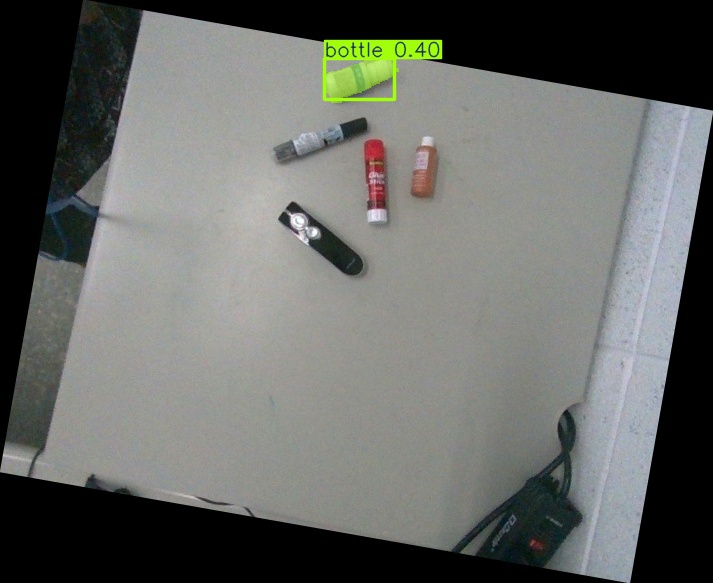

In [9]:
from IPython.display import Image as IPyImage

IPyImage(filename='/content/runs/segment/predict/image_6_rot350.jpg', width=600)

Train Model

In [13]:
!yolo task=segment mode=train model=yolo26m-seg.pt data=/content/custom_dataset.yaml epochs=50 imgsz=640

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/custom_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

In [15]:
!yolo task=segment mode=predict model=/content/runs/segment/train/weights/best.pt source="/content/drive/MyDrive/yolo26_dataset/valid/images/image_6_rot350.jpg" save=True conf=0.25

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26m-seg summary (fused): 149 layers, 23,511,323 parameters, 0 gradients, 121.2 GFLOPs

image 1/1 /content/drive/MyDrive/yolo26_dataset/valid/images/image_6_rot350.jpg: 544x640 (no detections), 84.5ms
Speed: 2.9ms preprocess, 84.5ms inference, 0.3ms postprocess per image at shape (1, 3, 544, 640)
Results saved to /content/runs/segment/predict-2
💡 Learn more at https://docs.ultralytics.com/modes/predict


Test Model



Running YOLO26 inference on 37 test images...

Loading model from: /content/runs/segment/train-2/weights/best.pt

image 1/37 /content/drive/MyDrive/yolo26_dataset/valid/images/image_6.jpg: 480x640 1 marker, 1 medicine, 1 remote, 1 paint, 1 glue_stick, 1228.8ms
image 2/37 /content/drive/MyDrive/yolo26_dataset/valid/images/image_6_rot000.jpg: 480x640 1 marker, 1 medicine, 1 remote, 1 paint, 1 glue_stick, 1047.5ms
image 3/37 /content/drive/MyDrive/yolo26_dataset/valid/images/image_6_rot010.jpg: 544x640 2 markers, 1 medicine, 1 remote, 1 paint, 1 glue_stick, 1152.1ms
image 4/37 /content/drive/MyDrive/yolo26_dataset/valid/images/image_6_rot020.jpg: 576x640 1 marker, 1 medicine, 1 remote, 1 paint, 1 glue_stick, 1216.0ms
image 5/37 /content/drive/MyDrive/yolo26_dataset/valid/images/image_6_rot030.jpg: 608x640 1 marker, 1 medicine, 1 remote, 1 paint, 1 glue_stick, 1330.4ms
image 6/37 /content/drive/MyDrive/yolo26_dataset/valid/images/image_6_rot040.jpg: 640x640 1 marker, 1 medicine, 1 remote,

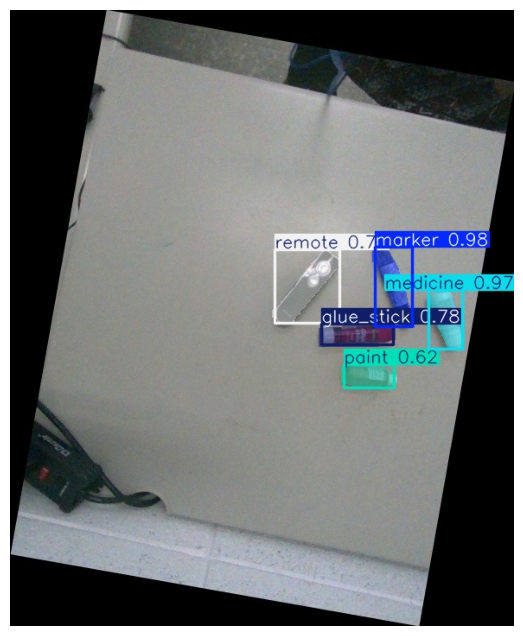

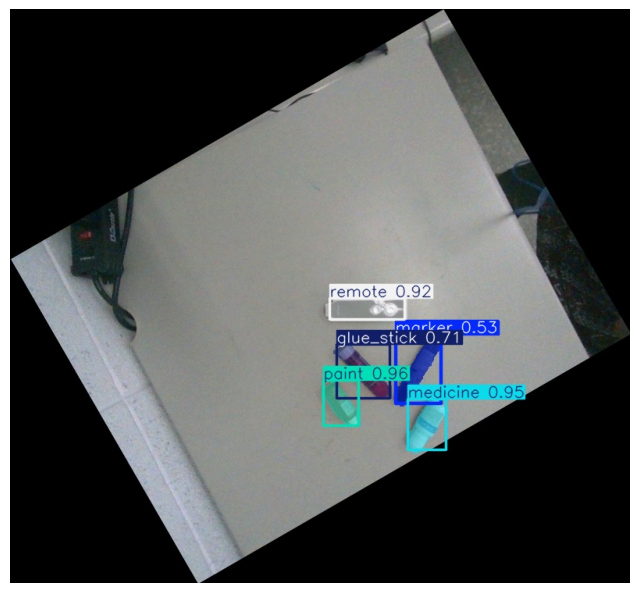

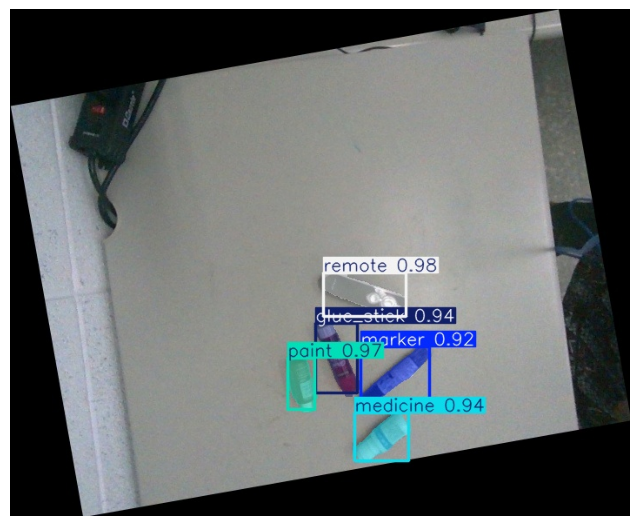

In [23]:

import glob
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt # Added matplotlib import for plt.figure and plt.imshow
from ultralytics import YOLO # Import YOLO

TEST_IMAGES_DIR = os.path.join(data_config['path'], data_config['val'])
test_image_files = glob.glob(os.path.join(TEST_IMAGES_DIR, "*.jpg")) + glob.glob(os.path.join(TEST_IMAGES_DIR, "*.png"))

if len(test_image_files) == 0:
    print(f"\n[WARNING] Zero files found in {TEST_IMAGES_DIR}. Check your images directory.")
else:
    print(f"\nRunning YOLO26 inference on {len(test_image_files)} test images...\n")

    # Load the trained model
    model_path = "/content/runs/segment/train-2"
    model = YOLO(model_path)

    inference_results = model.predict(
        source=TEST_IMAGES_DIR,
        imgsz=640,
        save=True,       # Saves the bounding boxes & mask overlays to disk automatically
        conf=0.25,       # Confidence threshold
        device='cpu'
    )

    predict_dirs = sorted(glob.glob("runs/segment/predict*"))
    if predict_dirs:
        latest_predict_dir = predict_dirs[-1]
        predicted_outputs = glob.glob(f"{latest_predict_dir}/*.jpg") + glob.glob(f"{latest_predict_dir}/*.png")

        print(f"\nDisplaying annotated predictions from: {latest_predict_dir}")
        for img_path in predicted_outputs[:3]: # Limit to 3 images to prevent notebook bloat
            img = Image.open(img_path)
            plt.figure(figsize=(8, 8))
            plt.imshow(img)
            plt.axis('off')
            plt.show()
    else:
        print("✗ No saved visualization images found in runs/segment/predict*")